# 다중 회귀
- 다중의 독립 변수가 존재하는 회귀 분석
- 여러개의 독립 변수가 복합적으로 종속 변수에 영향을 미치는 경우 다중 회귀 모형으로 데이터를 예측
- 다중 회귀 최적의 모델을 결정하기 위해 여러 가지의 방법이 존재
- 모델이 복잡해지면 과대적합 발생할 가능성이 있기 때문에 이를 방지하기 위해 다양한
규제 방식이 존재하고 규제에 따른 모델들이 존재
    - 모델에서 규제 방식에 따라서 가중치를 변화시킨다
    - 독립 변수에서의 가중치가 0 이 되는 차원(컬럼 | 피쳐)들이 생성
    - 규제를 강하게 걸면 가중치의 절대치가 줄어들고 0에 가까워진다


## 릿지
- 최소제곱 적합식의 수축 페널티라 불리는 항에 L2 페널티를 추가한것

- 매개변수
    - alpha
        - 기본값 : 1.0
        - 규제의 강도 -> 클수록 회귀 계수가 작아지고 과적합 방지, 과소적합 위험
        - 해당 모델의 중요한 매개변수
    - solver
        - 기본값 : 'auto'
        - 해를 구하는 방법
        - 데이터의 크기 / 희소성에 따라 적합한 solver를 선택
        - 'auto', 'svd', 'cholesky', 'lspr', 'sparse_cg', 'sag', 'saga'
            - svd : 특이값 분해, 다중공선성 있고 데이터의 개수가 작거나 중간정도
            - cholesky : 정규방정식, 데이터의 개수가 작거나 중간 정도
            - lsqr : 반복 최소제곱, 대규모 데이터중 희소/밀집 데이터
            - space_cg : 공액 기울기법, 대규모 데이터 중 희소 데이터
            - sag : 확률적 평균 검사, 데이터의 행의 수가 열의 수보다 월등히 많은 경우
            - saga : sag 확장, 대규모 희소, ElasticNet 가능
    
    - tol
        - 기본값 : 0.01 (1e-03)
        - 수렴의 판단 기준, 작을수록 정밀, 속도적인 면에서 느려질 수 있다.
    - max_iter
        - 기본값 : None
        - 최적화 될때까지 최대 반복 횟수.(데이터가 크거나 수치가 불안정한 경우 필요)

    - 속성
        - coef_
            - 회귀 계수를 출력(규제로 인해서 선형 회귀에 비해 값들이 작게 출력)
        - n_iter
            - solver가 반복한 횟수 출력


In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [3]:
diabetes = load_diabetes()

In [4]:
df = pd.DataFrame(diabetes['data'], columns= diabetes['feature_names'])
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [53]:
alpha = np.logspace(-3, 1, 3)
alpha

array([1.e-03, 1.e-01, 1.e+01])

In [14]:
# alpha 값에 따라서 회귀계수가 어떻게 변화하는가?
# 반복 실행할때 마다 회귀계수를 추가해주는 빈 리스트
data = []

for a in alpha:
    # print(a)
    # Ridge클래스 생성 시 alpha 매개변수에 a 대입
    ridge = Ridge(alpha=a)
    # 모델 학습
    ridge.fit(df.values, diabetes['target'])
    # 학습 된 모델에서 회귀계수를 출력하여 data에 추가
    data.append(
        ridge.coef_
    )

pd.DataFrame(data)

,0,1,2,3,4,5,6,7,8,9
0,-9.549162,-239.086958,520.369375,323.822745,-712.322159,413.379125,65.811323,167.513007,720.939924,68.123360
1,-7.197534,-234.549764,520.588601,320.517131,-380.607135,150.484671,-78.589275,130.312521,592.347959,71.134844
2,1.308705,-207.192418,489.695171,301.764058,-83.466034,-70.826832,-188.678898,115.712136,443.812917,86.749315
3,29.466112,-83.154276,306.352680,201.627734,5.909614,-29.515495,-152.040280,117.311732,262.944290,111.878956
4,19.812842,-0.918430,75.416214,55.025160,19.924621,13.948715,-47.553816,48.259433,70.143948,44.213892


In [18]:
df_ridge = pd.DataFrame(data, index=alpha, columns=df.columns)

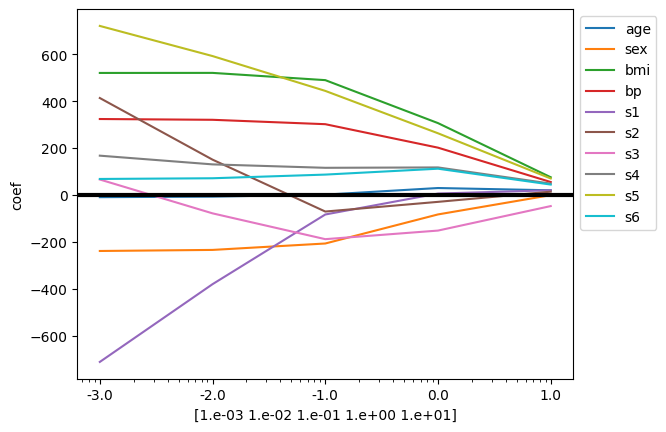

In [24]:
plt.semilogx(df_ridge)
plt.xticks(alpha, labels=np.log10(alpha))
plt.legend(labels = df_ridge.columns, bbox_to_anchor = (1,1))
plt.xlabel(alpha)
plt.ylabel('coef')
plt.axhline(y = 0, color='black', linewidth = 3 )

plt.show()

In [25]:
# 단순 선형 회귀와 릿지 회귀 의 회귀 계수를 확인
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(
    df.values,
    diabetes['target']
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


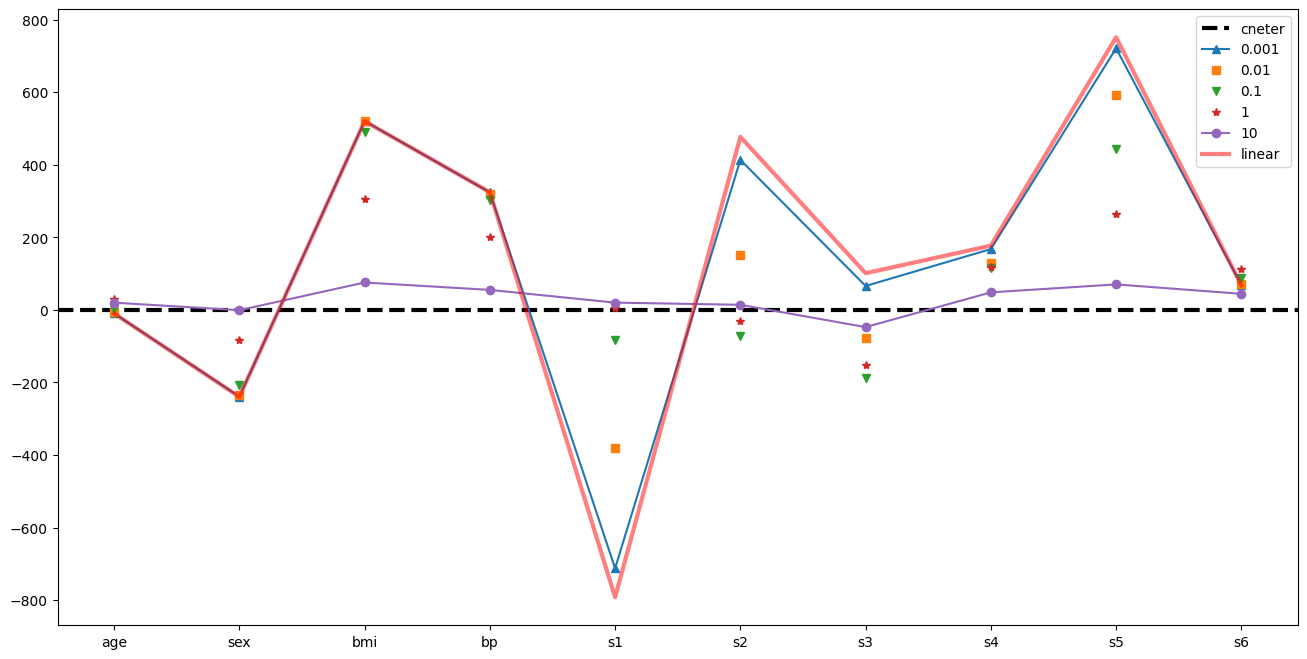

In [41]:
plt.figure(figsize=(16,8))
plt.axhline(y = 0,linestyle = '--', linewidth =3, color = 'black')
plt.plot(df_ridge.loc[0.001,], '^-')
plt.plot(df_ridge.loc[0.01,], 's')
plt.plot(df_ridge.loc[0.1,], 'v')
plt.plot(df_ridge.loc[1.0,], '*')
plt.plot(df_ridge.loc[10.0,], 'o-')
plt.plot(lr.coef_, 'r', linewidth = 3, alpha = 0.5)
plt.legend(['cneter',0.001,0.01,0.1,1,10,'linear'], bbox_to_anchor=(1,1))

plt.show()


- 연습
    - train 과 test 비율은 8:2
    - 당뇨 데이터를 이용하여 단순 선형 회귀를 이용하여 학습, 평가를 하여 평가 지표 mse값을 확인하고
    - 릿지 회귀를 이용하여 alpha 0.01, 0.1, 1.0 인 경우로 학습, 평가를 하여 평가 지표 mse값을
    확인하여 비교

In [43]:
from sklearn.model_selection import train_test_split

In [ ]:
df

In [58]:
x = df.values
y = diabetes['target']

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
    )


In [61]:
lr = LinearRegression()

In [62]:
lr.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
from sklearn.metrics import mean_squared_error, r2_score

In [64]:
ridge_1 = Ridge(alpha=0.01)
ridge_2 = Ridge(alpha=0.1)
ridge_3 = Ridge(alpha=1)


In [66]:
# 학습한 모델들을 이용하여 예측용 독립 변수를 대입하여 예측 값을 저장

ridge_1.fit(X_train, Y_train)
ridge_2.fit(X_train, Y_train)
ridge_3.fit(X_train, Y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [71]:
lr_pred = lr.predict(X_test)
ridge_1_pred = ridge_1.predict(X_test)
ridge_2_pred = ridge_2.predict(X_test)
ridge_3_pred = ridge_3.predict(X_test)

In [73]:
mse_lr = mean_squared_error(Y_test, lr_pred)
mse_ridge_1 = mean_squared_error(Y_test, ridge_1_pred)
mse_ridge_2 = mean_squared_error(Y_test, ridge_2_pred)
mse_ridge_3 = mean_squared_error(Y_test, ridge_3_pred)

In [74]:
print(round(mse_lr,2))
print(round(mse_ridge_1,2))
print(round(mse_ridge_2,2))
print(round(mse_ridge_3,2))


2900.19
2882.29
2856.49
3077.42


### 라쏘
- 최소 제곱 적합식의 수축 페널티라 불리는 항에 L1 페널티를 추가한것
- 릿지 회귀가 변수의 크기가 매우 큰 데이터인 경우에는 결과를 해석하는데 어려움
발생하는데 이러한 문제를 해결하기 위한 방법

- 매개변수
    - alpha
        - 기본값 : 1.0
        - 규제 강도. 클수록 많은 회귀계수가 0이 됨(feature select)
        - 규제 강도가 너무 큰 경우에는 많은 컬럼의 회귀계수가 0이 되어 단순한 데이터(과소적합)
    - selection
        - 기본값 : 'cyclic'
        - 좌표측 경사법 업데이트 순서
            - cyclic : 순차적으로 업데이트
            - random : 무작위로 업데이트
        - 피쳐의 순서대로 가중치를 적용할 것인가? 아니면 무작위 선택으로 가중치를 적용할 것인가?
    - percompute
        - 기본값 : auto
        - Gram matrix의 미리 계산의 여부
        - 그람 행렬은 선형 대수에서 자주 쓰이는 개념
        - 회귀 분석에서 핵심적인 부분
    - warm_start
        - 기본값 : False
        - 이전의 학습 결과를 이어서 학습을 할지 지정
        

In [75]:
from sklearn.linear_model import Lasso

In [78]:
alpha = np.logspace(-3, 1, 5)
# 모델이 학습을 하고 생성된 회귀 계수를 추가하는 공간인 빈 리스트 생성
data = []

for a in alpha:
    # print(a)
    lasso  = Lasso(alpha=a)
    # 모델을 학습
    lasso.fit(df.values,diabetes['target'])
    data.append(lasso.coef_)

lasso_df = pd.DataFrame(data, index= alpha, columns=df.columns)
lasso_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.001,-8.996177,-238.896328,520.267403,323.423596,-720.244828,421.399753,66.733503,164.448022,725.335558,67.476810
0.010,-1.304662,-228.819129,525.566130,316.168834,-307.016211,89.324647,-105.078369,119.597616,571.330356,65.008383
0.100,-0.000000,-155.359976,517.186795,275.077235,-52.539365,-0.000000,-210.157991,0.000000,483.912648,33.673965
1.000,0.000000,-0.000000,367.703860,6.298858,0.000000,0.000000,-0.000000,0.000000,307.605418,0.000000
10.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


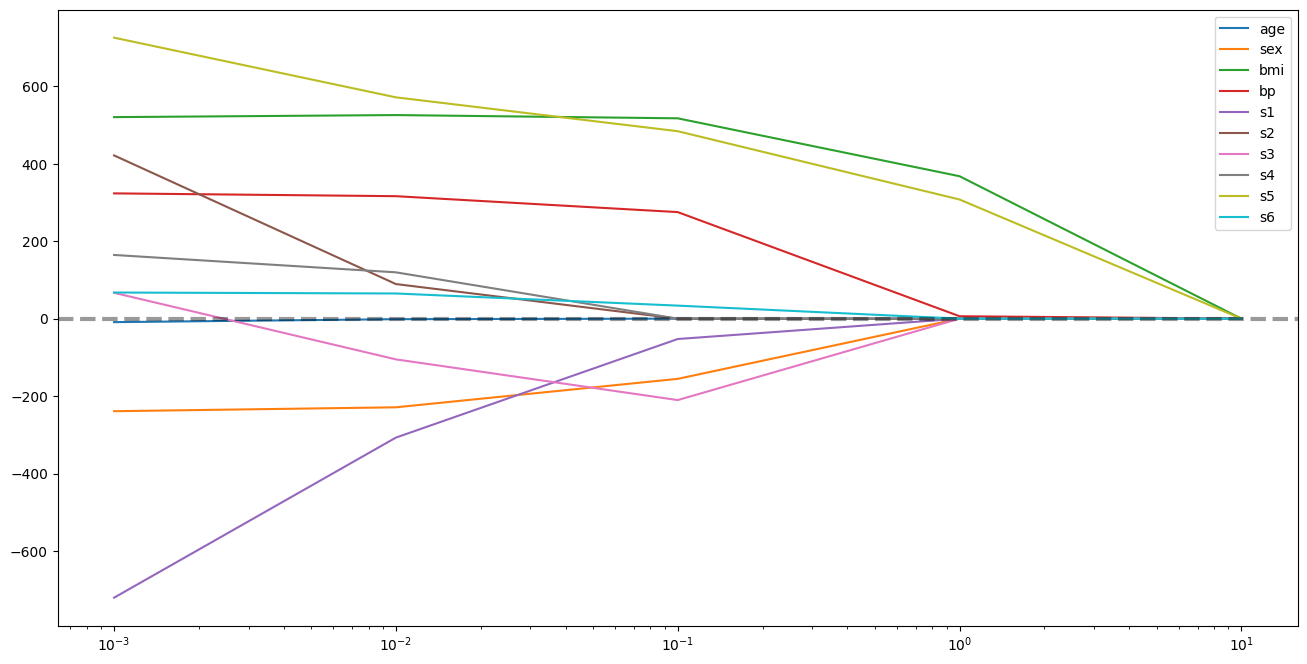

In [84]:
# 회귀 계수를 그래프 시각화
plt.figure(figsize=(16,8))
plt.semilogx(lasso_df)
# y = 0 보조선 추가
plt.axhline(y = 0, linestyle = '--', color = 'black', linewidth = 3, alpha =0.4 )
plt.legend(labels = lasso_df.columns, bbox_to_anchor=(1,1))


plt.show()

In [85]:
lr = LinearRegression()
lr.fit(df.values, diabetes['target'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


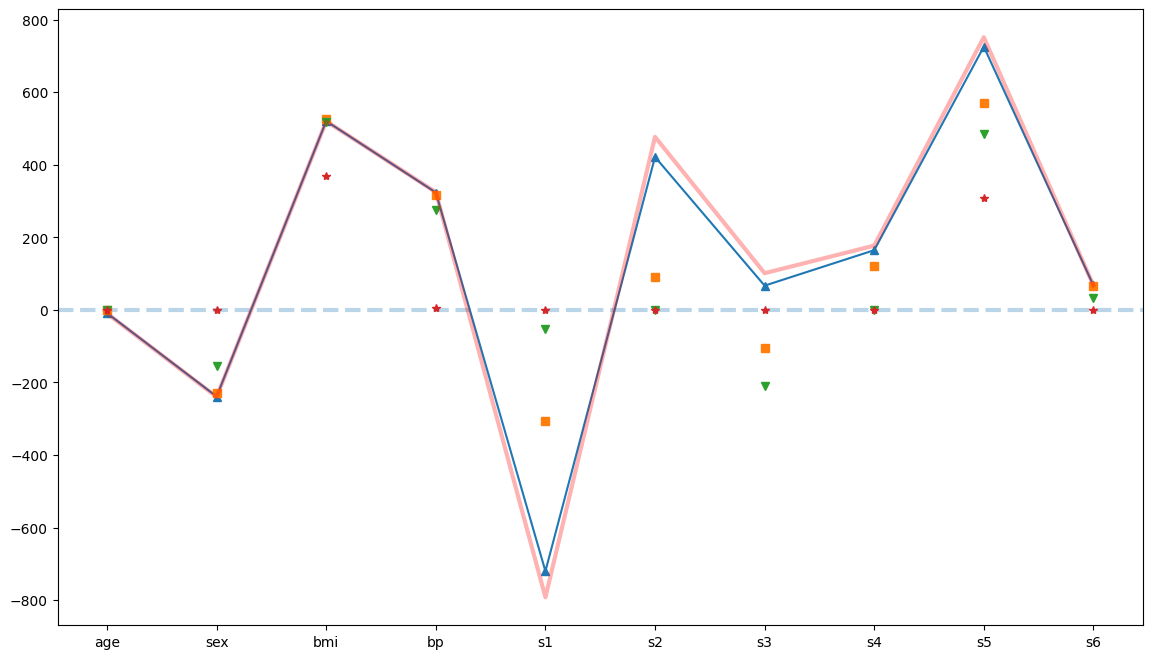

In [87]:
plt.figure(figsize=(14,8))

plt.axhline(y = 0, linestyle = '--', linewidth = 3, alpha = 0.3)
plt.plot(lasso_df.loc[0.001, ], '^-', label = 'Lasso 0.001')
plt.plot(lasso_df.loc[0.01, ], 's', label = 'Lasso 0.01')
plt.plot(lasso_df.loc[0.1, ], 'v', label = 'Lasso 0.1')
plt.plot(lasso_df.loc[1, ], '*', label = 'Lasso 1')
plt.plot(lr.coef_, 'r', linewidth =3, alpha = 0.3)

plt.show()

- 연습
    - 단순 선형 회귀, Lasso 모델을 이용하여 당뇨병 데이터 학습을 시키고 평가를 하여 평가 지표를 하나 생성
        - Lasso Alpha는 0.01, 0.1 2개의 모델을 생성
    - mse, r2_score의 값들을 비교

In [90]:
np.logspace(-2,0,3)

array([0.01, 0.1 , 1.  ])

In [92]:
alpha = np.logspace(-2,0,2)
data = []

for a in alpha:
    # print(a)
    lasso  = Lasso(alpha=a)
    # 모델을 학습
    lasso.fit(df.values,diabetes['target'])
    data.append(lasso.coef_)

lasso_df = pd.DataFrame(data, index= alpha, columns=df.columns)
lasso_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.01,-1.304662,-228.819129,525.56613,316.168834,-307.016211,89.324647,-105.078369,119.597616,571.330356,65.008383
1.00,0.000000,-0.000000,367.70386,6.298858,0.000000,0.000000,-0.000000,0.000000,307.605418,0.000000


In [99]:
x = df.values
y = diabetes['target']

In [100]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
    )

In [ ]:
# 모델 생성
lr = LinearRegression()
lasso1 = Lasso(alpha=0.01)
lasso2 = Lasso(alpha=0.1)
lasso3 = Lasso(alpha=1)

In [111]:
# 데이터 학습
lr.fit(X_train, Y_train)
lasso1.fit(X_train, Y_train)
lasso2.fit(X_train, Y_train)
lasso3.fit(X_train, Y_train)

,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [112]:
# 학습된 모델을 이용하여 예측
pred_lr = lr.predict(X_test)
pred_lasso1 = lasso1.predict(X_test)
pred_lasso2 = lasso2.predict(X_test)
pred_lasso3 = lasso3.predict(X_test)

In [115]:
# 평가 지표 mse 생성
mse_lr = mean_squared_error(Y_test, pred_lr)
mse_lasso1 = mean_squared_error(Y_test, pred_lasso1)
mse_lasso2 = mean_squared_error(Y_test, pred_lasso2)
mse_lasso3 = mean_squared_error(Y_test, pred_lasso3)

In [117]:
mse_lr = mean_squared_error(Y_test, pred_lr)
r2_lr = r2_score(Y_test, pred_lr)
print(f"MSE: {round(mse_lr,2)}")
print(f"R2 Score: {round(r2_lr,2)}")
print(f"lasso1: {round(mse_lasso1,2)}")
print(f"lasso2: {round(mse_lasso2,2)}")
print(f"lasso3: {round(mse_lasso3,2)}")

MSE: 2848.31
R2 Score: 0.48
lasso1: 2831.0
lasso2: 2753.92
lasso3: 3433.16


In [106]:
pred_lasso = lasso.predict(X_test)    
mse_lasso = mean_squared_error(Y_test, pred_lasso)
r2_lasso = r2_score(Y_test, pred_lasso)
print(alpha, round(mse_lasso,2), round(r2_lasso,2))

[0.01 1.  ] 3363.14 0.39


## 엘라스틱넷
- 릿지 회귀, 라쏘 회귀를 절충한 알고리즘
- L1, L2 페널티를 혼합 -> 혼합의 비율을 지정

- 매개변수
    - alpha
        - 기본값 : 1
        - 전체 규제의 강도
    - l1_ratio
        - 기본값 : 0.5
        - L1 페널티의 비중
        - 0 : 릿지 회귀
        - 1 : 라쏘 회귀
        - 0과 1사이의 값 : 엘라스틱넷
- 라쏘가 과도하게 변수를 제거하거나 릿지가 과적합을 충분하게 억제 하지 못하는 경우에 중간의 타협안으로 사용


In [118]:
from sklearn.linear_model import ElasticNet

In [ ]:
alpha = np.logspace(-3, 1, 5)

data = []

for a in alpha:
    ela = ElasticNet(alpha=0)
    ela.fit(x,y)
    data.append(ela.coef_)

ela_df = pd.DataFrame(data, index=alpha, columns=df.columns)
ela_df

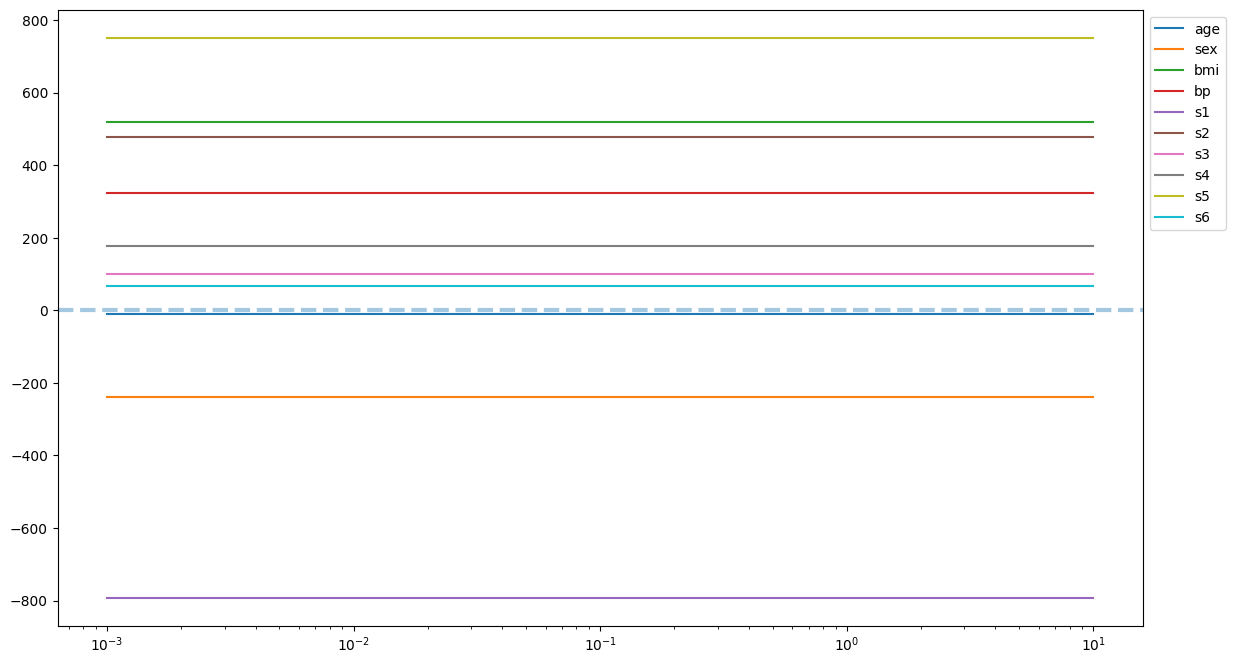

In [120]:
# 회귀 계수를 시각화
plt.figure(figsize=(14,8))
plt.semilogx(ela_df)

plt.legend(labels = ela_df.columns, bbox_to_anchor=(1,1))

plt.axhline(y=0, linestyle = '--', linewidth = 3 ,alpha=0.4)

- 연습
    - sklearn 라이브러리 안에 datasets들 중에 fetch_california_housing 함수를 로드
    - 해당 함수를 이용하여 샘플 데이터를 변수에 저장
    - 샘플 데이터에서 독립 변수와 종속 변수를 X, Y에 대입하여 저장
    - train, test의 비율은 7:3의 비율로 데이터의 분할
    - 단순 선형 회귀, 엘라스틱넷을 이용하여 모델의 성능을 검증
        - alpha : 0.01, 0.1, 1
        - li_ratio : 0, 0.5, 1
    
    - 평가 지표는 mse를 이용
    - 가장 성능이 좋은 모델을 확인

In [123]:
from sklearn.datasets import fetch_california_housing

In [125]:
data = fetch_california_housing()

In [ ]:
df.info()

In [127]:
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [129]:
print("모델 1: 단순 선형 회귀")
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, pred_lr)
print(f"MSE: {round(mse_lr,2)}")

모델 1: 단순 선형 회귀
MSE: 0.53


In [130]:
alphas = [0.01, 0.1, 1]
l1_ratios = [0, 0.5, 1]

results = {}

for alpha in alphas:
    for l1_ratio in l1_ratios:
        # 모델 생성 및 학습
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
        model.fit(X_train, y_train)
        
        # 예측 및 MSE 계산
        pred = model.predict(X_test)
        mse = mean_squared_error(y_test, pred)
        
        model_name = f"alpha={alpha}, l1_ratio={l1_ratio}"
        print(f"  -> {model_name} | MSE: {mse:.4f}")
        results[model_name] = mse

c:\Users\johnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.853e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


  -> alpha=0.01, l1_ratio=0 | MSE: 0.5258
  -> alpha=0.01, l1_ratio=0.5 | MSE: 0.5252
  -> alpha=0.01, l1_ratio=1 | MSE: 0.5253


c:\Users\johnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.208e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


  -> alpha=0.1, l1_ratio=0 | MSE: 0.5340
  -> alpha=0.1, l1_ratio=0.5 | MSE: 0.5571
  -> alpha=0.1, l1_ratio=1 | MSE: 0.5971
  -> alpha=1, l1_ratio=0 | MSE: 0.6228
  -> alpha=1, l1_ratio=0.5 | MSE: 0.7563
  -> alpha=1, l1_ratio=1 | MSE: 0.9345


c:\Users\johnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.532e+03, tolerance: 1.936e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [131]:
best_model_name = min(results, key=results.get)
best_mse = results[best_model_name]

print(f'best model = {best_model_name}')
print(f'best mse = {best_mse}')

best model = alpha=0.01, l1_ratio=0.5
best mse = 0.5251543054669675
